# Day 4 — Session 3 Support Notebook
## Data Preparation and Feature Engineering for Applied AI

**Session goal:** Convert a raw, imperfect engineering dataset into a defensible machine-learning-ready representation.

This notebook demonstrates:

- loading and auditing a DataFrame;
- correcting data types and inconsistent categories;
- handling duplicates and missing values;
- identifying outliers;
- preventing data leakage;
- scaling numerical variables;
- encoding categorical variables;
- creating domain-informed features;
- fitting preprocessing only on training data;
- comparing a simple model with a baseline;
- estimating initial feature importance.

The objective is not to optimize predictive accuracy. It is to make the data pipeline **transparent, repeatable, and scientifically defensible**.

## Learning outcomes

By the end of the notebook, faculty should be able to:

1. Identify common data-quality problems before model development.
2. Distinguish identifiers, inputs, targets, metadata, and leakage variables.
3. Prepare numerical and categorical variables using a scikit-learn pipeline.
4. Create features that represent disciplinary knowledge.
5. Explain why preprocessing must be learned from training data only.
6. Compare a prepared model with a simple baseline.

## 1. Load the raw dataset

Each row represents one manufacturing process run. The target is whether the run produced a defective part.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


raw = pd.read_csv("raw_process_quality_data.csv")

print("Dataset shape:", raw.shape)
raw.head()

Dataset shape: (242, 11)


,run_id,timestamp,temperature_c,pressure_kpa,speed_mm_s,vibration_mm_s,material_type,shift,final_quality_score,maintenance_action_after_run,defect
0,RUN-0001,2026-01-05 07:00:00,199.01,476.8,33.13,3.843,B,Day,89.01,Inspection,1
1,RUN-0002,2026-01-05 07:45:00,199.55,459.35,58.30,2.622,A,Day,88.20,Inspection,1
2,RUN-0003,2026-01-05 08:30:00,204.30,480.03,54.05,3.771,B,Day,91.63,NaN,0
3,RUN-0004,2026-01-05 09:15:00,211.97,496.35,44.11,3.303,B,Day,88.63,Inspection,1
4,RUN-0005,2026-01-05 10:00:00,204.24,562.1,50.01,2.448,A,Day,95.04,NaN,0


## 2. Conduct an initial data audit

In [3]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_count": raw.isna().sum(),
    "unique_values": raw.nunique(dropna=True)
})

display(audit)
print("Duplicate rows:", raw.duplicated().sum())

,dtype,missing_count,unique_values
run_id,object,0,240
timestamp,object,0,240
temperature_c,float64,5,225
pressure_kpa,object,6,231
speed_mm_s,float64,0,229
vibration_mm_s,float64,7,225
material_type,object,4,6
shift,object,0,5
final_quality_score,float64,0,211
maintenance_action_after_run,object,188,1


Duplicate rows: 2


In [4]:
print("Target counts:")
display(raw["defect"].value_counts().sort_index().to_frame("count"))

print("Target proportions:")
display(
    raw["defect"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("proportion")
    .to_frame()
)

Target counts:


,count
defect,
0,188
1,54


Target proportions:


,proportion
defect,
0,0.77686
1,0.22314


### Checkup

- Which column has the wrong data type?
- Which columns contain missing values?
- Is the target balanced?
- Which columns may be identifiers or metadata rather than inputs?

## 3. Inspect inconsistent categories and invalid numerical values

In [5]:
print("Material categories:")
print(sorted(raw["material_type"].dropna().astype(str).unique()))

print("\nShift categories:")
print(sorted(raw["shift"].dropna().astype(str).unique()))

print("\nExample pressure values:")
print(raw["pressure_kpa"].dropna().astype(str).sample(12, random_state=2).tolist())

Material categories:
[' a', 'A', 'B', 'B ', 'C', 'c']

Shift categories:
['Day', 'Evening', 'NIGHT', 'Night', 'day']

Example pressure values:
['594.28', '491.04', '582.84', '547.47', '556.65', '527.91', '500.95', '536.09', '556.05', '607.3', '493.11', '537.5']


## 4. Create a cleaned working copy

In [6]:
df = raw.copy()
df = df.drop_duplicates().reset_index(drop=True)

df["material_type"] = (
    df["material_type"]
    .astype("string")
    .str.strip()
    .str.upper()
    .astype(object)
)

df["shift"] = (
    df["shift"]
    .astype("string")
    .str.strip()
    .str.title()
    .astype(object)
)

df["material_type"] = df["material_type"].where(pd.notna(df["material_type"]), np.nan)
df["shift"] = df["shift"].where(pd.notna(df["shift"]), np.nan)

df["pressure_kpa"] = pd.to_numeric(
    df["pressure_kpa"]
    .astype("string")
    .str.replace(" kPa", "", regex=False),
    errors="coerce"
)

print("Cleaned material categories:", sorted(pd.Series(df["material_type"]).dropna().unique()))
print("Cleaned shift categories:", sorted(pd.Series(df["shift"]).dropna().unique()))
print("Duplicate rows remaining:", df.duplicated().sum())
print("Pressure dtype:", df["pressure_kpa"].dtype)

Cleaned material categories: ['A', 'B', 'C']
Cleaned shift categories: ['Day', 'Evening', 'Night']
Duplicate rows remaining: 0
Pressure dtype: Float64


## 5. Identify outliers

Outliers may be sensor failures, data-entry errors, rare valid conditions, or important failures. Use disciplinary limits rather than deleting values automatically.

In [7]:
numeric_audit_columns = [
    "temperature_c",
    "pressure_kpa",
    "speed_mm_s",
    "vibration_mm_s"
]

df[numeric_audit_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_c,235.0,204.092979,9.01094,178.41,199.285,203.61,208.71,278.0
pressure_kpa,233.0,511.527811,38.625258,418.77,487.6,509.76,536.28,628.37
speed_mm_s,240.0,49.353833,5.517677,33.13,46.295,49.12,53.385,66.37
vibration_mm_s,233.0,2.606472,1.184334,0.0,1.979,2.525,3.146,14.5


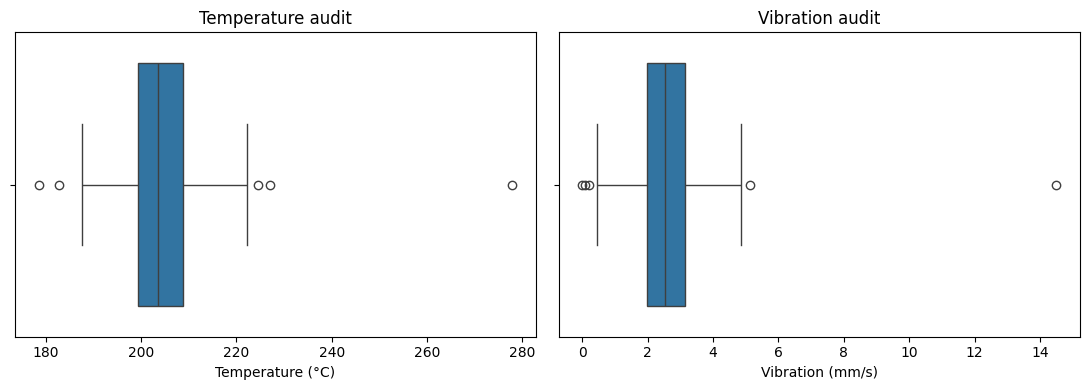

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x="temperature_c", ax=axes[0])
axes[0].set_title("Temperature audit")
axes[0].set_xlabel("Temperature (°C)")

sns.boxplot(data=df, x="vibration_mm_s", ax=axes[1])
axes[1].set_title("Vibration audit")
axes[1].set_xlabel("Vibration (mm/s)")

plt.tight_layout()
plt.show()

### Apply documented plausibility rules

Assume the equipment specifications indicate:

- valid temperature range: 150–240 °C;
- valid vibration range: 0–8 mm/s.

In [9]:
df.loc[~df["temperature_c"].between(150, 240), "temperature_c"] = np.nan
df.loc[~df["vibration_mm_s"].between(0, 8), "vibration_mm_s"] = np.nan

df[["temperature_c", "vibration_mm_s"]].isna().sum()

,0
temperature_c,6
vibration_mm_s,8


## 6. Prevent data leakage

In [10]:
roles = pd.DataFrame([
    ["run_id", "Identifier", "Remove from model inputs"],
    ["timestamp", "Metadata", "Use only for justified time features"],
    ["temperature_c", "Candidate input", "Available during the process"],
    ["pressure_kpa", "Candidate input", "Available during the process"],
    ["speed_mm_s", "Candidate input", "Available during the process"],
    ["vibration_mm_s", "Candidate input", "Available during the process"],
    ["material_type", "Candidate input", "Known before the run"],
    ["shift", "Candidate input", "Known before the run"],
    ["final_quality_score", "Leakage", "Measured after final inspection"],
    ["maintenance_action_after_run", "Leakage", "Recorded after the outcome"],
    ["defect", "Target", "Outcome to predict"],
], columns=["column", "role", "reason"])

roles

,column,role,reason
0,run_id,Identifier,Remove from model inputs
1,timestamp,Metadata,Use only for justified time features
2,temperature_c,Candidate input,Available during the process
3,pressure_kpa,Candidate input,Available during the process
4,speed_mm_s,Candidate input,Available during the process
5,vibration_mm_s,Candidate input,Available during the process
6,material_type,Candidate input,Known before the run
7,shift,Candidate input,Known before the run
8,final_quality_score,Leakage,Measured after final inspection
9,maintenance_action_after_run,Leakage,Recorded after the outcome


## 7. Create domain-informed features

In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df["temperature_deviation_c"] = (df["temperature_c"] - 204).abs()
df["pressure_deviation_kpa"] = (df["pressure_kpa"] - 510).abs()
df["process_intensity"] = df["speed_mm_s"] * df["pressure_kpa"]
df["hour_of_day"] = df["timestamp"].dt.hour

df[[
    "temperature_c",
    "temperature_deviation_c",
    "pressure_kpa",
    "pressure_deviation_kpa",
    "speed_mm_s",
    "process_intensity",
    "hour_of_day"
]].head()

,temperature_c,temperature_deviation_c,pressure_kpa,pressure_deviation_kpa,speed_mm_s,process_intensity,hour_of_day
0,199.01,4.99,476.8,33.2,33.13,15796.384,7
1,199.55,4.45,459.35,50.65,58.30,26780.105,7
2,204.30,0.30,480.03,29.97,54.05,25945.6215,8
3,211.97,7.97,496.35,13.65,44.11,21893.9985,9
4,204.24,0.24,562.1,52.1,50.01,28110.621,10


## 8. Define inputs and target

In [12]:
numeric_features = [
    "temperature_c",
    "pressure_kpa",
    "speed_mm_s",
    "vibration_mm_s",
    "temperature_deviation_c",
    "pressure_deviation_kpa",
    "process_intensity",
    "hour_of_day"
]

categorical_features = ["material_type", "shift"]
target = "defect"

X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

for col in categorical_features:
    X[col] = X[col].astype(object)
    X[col] = X[col].where(pd.notna(X[col]), np.nan)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (240, 10)
Target shape: (240,)


## 9. Split before learning preprocessing parameters

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 180
Test observations: 60


## 10. Build the preprocessing pipeline

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature_c',
                                                   'pressure_kpa', 'speed_mm_s',
                                                   'vibration_mm_s',
                                                   'temperature_deviation_c',
                                                   'pressure_deviation_kpa',
                                                   'process_intensity',
                                                   'hour_of_day']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['material_type',
                                                   'shift'])])),
                ('classifier', LogisticRegression(max_iter=2000))])

## 11. Establish a baseline and train the prepared model

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

majority_class = y_train.mode()[0]
baseline_predictions = np.full(len(y_test), majority_class) # we predict the majority class for all test samples

model.fit(X_train, y_train)
predictions = model.predict(X_test)

def classification_metrics(actual, predicted):
    return {
        "accuracy": accuracy_score(actual, predicted),
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "f1": f1_score(actual, predicted, zero_division=0)
    }

comparison = pd.DataFrame([
    {"method": "Majority-class baseline",
     **classification_metrics(y_test, baseline_predictions)},
    {"method": "Prepared logistic regression",
     **classification_metrics(y_test, predictions)}
])

comparison.round(3)

,method,accuracy,precision,recall,f1
0,Majority-class baseline,0.783,0.0,0.000,0.000
1,Prepared logistic regression,0.783,0.5,0.385,0.435


In [16]:
cm = confusion_matrix(y_test, predictions)

pd.DataFrame(
    cm,
    index=["Actual acceptable", "Actual defect"],
    columns=["Predicted acceptable", "Predicted defect"]
)

,Predicted acceptable,Predicted defect
Actual acceptable,42,5
Actual defect,8,5


## 12. Examine initial feature importance

Permutation importance is exploratory and does not establish causality.

In [17]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=15,
    random_state=42
)

importance_table = pd.DataFrame({
    "feature": X_test.columns,
    "mean_importance": importance.importances_mean,
    "standard_deviation": importance.importances_std
}).sort_values("mean_importance", ascending=False)

importance_table.round(4)

,feature,mean_importance,standard_deviation
3,vibration_mm_s,0.2723,0.0870
8,material_type,0.0958,0.0518
5,pressure_deviation_kpa,0.0555,0.0944
4,temperature_deviation_c,0.0463,0.1148
9,shift,0.0237,0.0335
6,process_intensity,0.0072,0.0089
7,hour_of_day,0.0020,0.0208
1,pressure_kpa,0.0000,0.0000
0,temperature_c,-0.0152,0.0683
2,speed_mm_s,-0.0540,0.0417


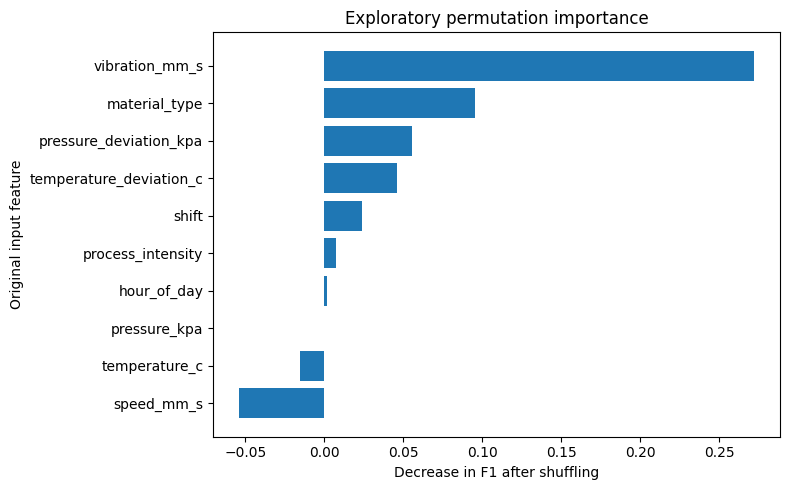

In [18]:
plot_table = importance_table.sort_values("mean_importance")

plt.figure(figsize=(8, 5))
plt.barh(plot_table["feature"], plot_table["mean_importance"])
plt.xlabel("Decrease in F1 after shuffling")
plt.ylabel("Original input feature")
plt.title("Exploratory permutation importance")
plt.tight_layout()
plt.show()

## 13. Activity: document the preprocessing decisions

In [19]:
preparation_record = {
    "Unit of observation": "One manufacturing process run",
    "Target": "Defect / acceptable",
    "Missing-value approach": "",
    "Outlier approach": "",
    "Categorical encoding": "",
    "Scaling approach": "",
    "Variables removed for leakage": [],
    "Domain-informed features created": [],
    "Primary evaluation metric": "",
    "Largest remaining data risk": ""
}

preparation_record

{'Unit of observation': 'One manufacturing process run',
 'Target': 'Defect / acceptable',
 'Missing-value approach': '',
 'Outlier approach': '',
 'Categorical encoding': '',
 'Scaling approach': '',
 'Variables removed for leakage': [],
 'Domain-informed features created': [],
 'Primary evaluation metric': '',
 'Largest remaining data risk': ''}

## 14. Session synthesis

A defensible preparation workflow should answer:

1. What does one row represent?
2. Which values are missing, invalid, duplicated, or inconsistent?
3. Which variables are available at prediction time?
4. Which variables leak the answer?
5. Which transformations are learned from training data?
6. Which engineered features encode meaningful disciplinary knowledge?
7. Does the prepared model improve on a simple baseline?
8. What limitation must be reported?

**Key principle:** Better preprocessing is not cosmetic. It changes what the model is allowed to learn and whether the evaluation is credible.

## Optional extension

- Remove engineered features and compare performance.
- Compare logistic regression with a shallow decision tree.
- Use grouped or time-aware splitting.
- Change the primary metric from F1 to recall.
- Investigate whether errors differ by material type or shift.